# Bitcoin

In [262]:
import matplotlib.pyplot as plt
import pandas as pd

In [263]:
import yfinance as yf

df = yf.download("BTC-USD", start="2000-01-01")

/Users/royjafari/.pyenv/versions/3.12.4/lib/python3.12/site-packages/yfinance/scrapers/history.py:173: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


In [264]:
n_top = 4
n_bottom = 4

In [265]:
df.columns = ['c','h','l','o','v']

In [266]:
df= df.reset_index()

In [267]:
bottoms = df.c.rolling(window=365).apply(lambda wdf:wdf.idxmin())
tops = df.c.rolling(window=365).apply(lambda wdf:wdf.idxmax())

In [268]:
bottoms_list = bottoms.value_counts()[:n_bottom].index.tolist()
tops_list = tops.value_counts()[:n_top].index.tolist()

In [269]:
bottoms_list.append(4304)

In [278]:
bottoms_list

[1550.0, 2987.0, 341.0, 4304]

In [270]:
bottoms_list.pop(bottoms_list.index(2003.0))
bottoms_list.pop(bottoms_list.index(2003.0))

2003.0

In [271]:
tops_list.pop(tops_list.index(1743.0))

1743.0

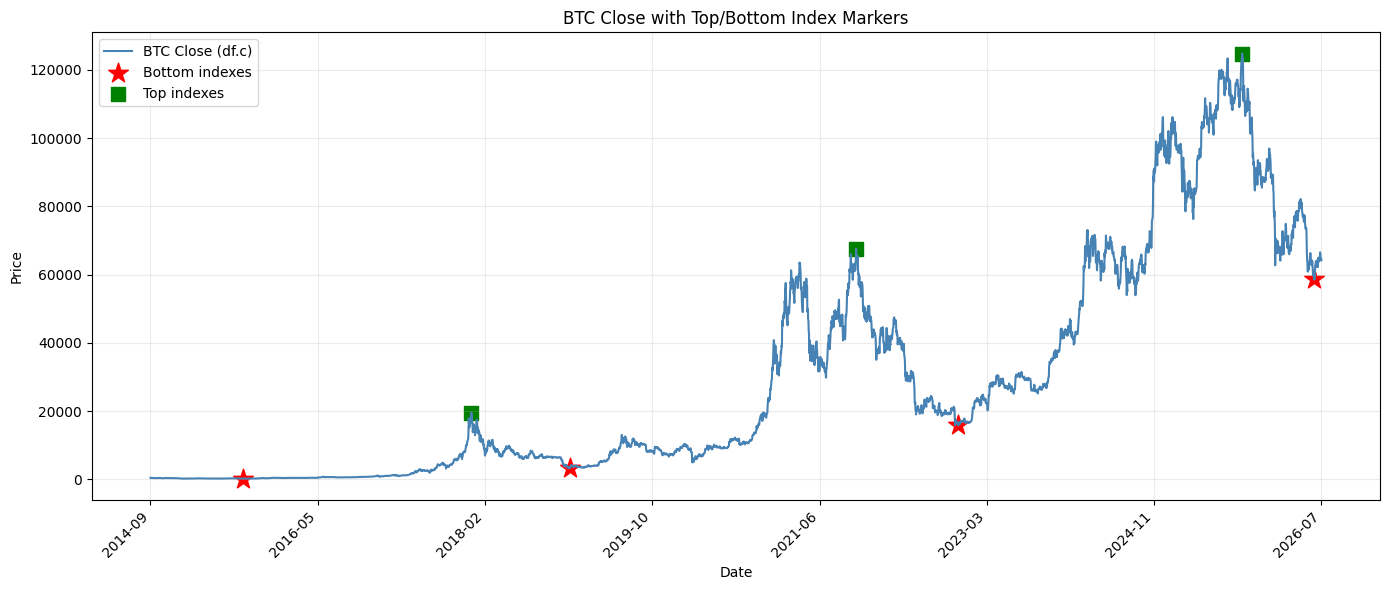

In [272]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df.c, label='BTC Close (df.c)', color='steelblue', linewidth=1.5)

bottom_idx = [int(i) for i in bottoms_list]
top_idx = [int(i) for i in tops_list]

ax.scatter(bottom_idx, df.loc[bottom_idx, 'c'], color='red', marker='*', s=220, label='Bottom indexes')
ax.scatter(top_idx, df.loc[top_idx, 'c'], color='green', marker='s', s=90, label='Top indexes')

ax.set_title('BTC Close with Top/Bottom Index Markers')
tick_idx = np.linspace(df.index.min(), df.index.max(), 8)
tick_idx = np.unique(np.clip(np.round(tick_idx).astype(int), df.index.min(), df.index.max()))
tick_dates = pd.to_datetime(df.loc[tick_idx, 'Date'])
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_dates.dt.strftime('%Y-%m'), rotation=45, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [273]:
import numpy as np

# Rebuild point arrays to avoid relying on prior local variables
bottom_idx = np.array(sorted(int(i) for i in bottoms_list), dtype=float)
top_idx = np.array(sorted(int(i) for i in tops_list), dtype=float)

bottom_prices = df.loc[bottom_idx.astype(int), 'c'].to_numpy(dtype=float)
top_prices = df.loc[top_idx.astype(int), 'c'].to_numpy(dtype=float)

# Linear regression (price = slope * index + intercept)
bottom_slope, bottom_intercept = np.polyfit(bottom_idx, bottom_prices, 1)
top_slope, top_intercept = np.polyfit(top_idx, top_prices, 1)

if np.isclose(bottom_slope, top_slope):
    raise ValueError('Top and bottom regression lines are nearly parallel; no stable intersection.')

# Solve for intersection between both lines
i_cross = (top_intercept - bottom_intercept) / (bottom_slope - top_slope)
p_cross = bottom_slope * i_cross + bottom_intercept

# Optional mapping from index to date (if inside data range)
if df.index.min() <= i_cross <= df.index.max():
    i_cross_nearest = int(round(i_cross))
    d_cross = df.loc[i_cross_nearest, 'Date']
else:
    i_cross_nearest = None
    d_cross = None

print(f'Bottom line: price = {bottom_slope:.4f} * idx + {bottom_intercept:.2f}')
print(f'Top line   : price = {top_slope:.4f} * idx + {top_intercept:.2f}')
print(f'Intersection index: {i_cross:.2f}')
print(f'Intersection price (BTC): ${p_cross:,.2f}')
if d_cross is not None:
    print(f'Nearest date in dataset: {d_cross.date()}')

Bottom line: price = 14.1434 * idx + -13017.88
Top line   : price = 36.9205 * idx + -25781.54
Intersection index: 560.37
Intersection price (BTC): $-5,092.29
Nearest date in dataset: 2016-03-30


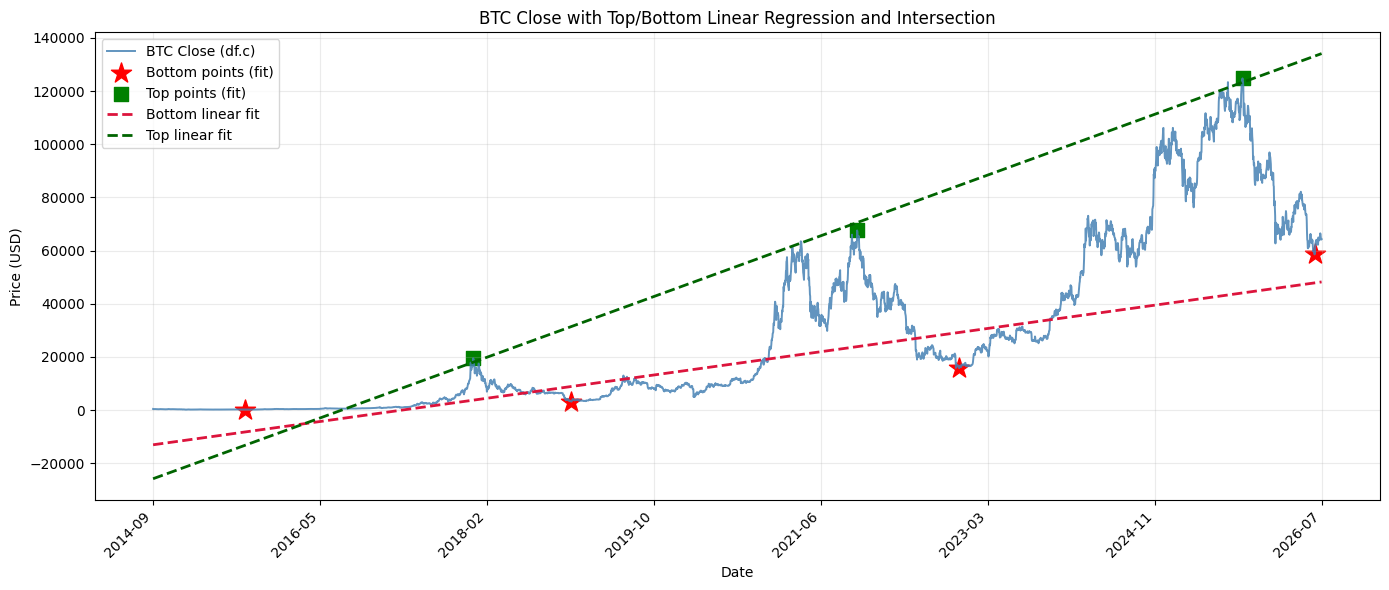

In [274]:
fig, ax = plt.subplots(figsize=(14, 6))

# Main BTC close series
ax.plot(df.index, df.c, label='BTC Close (df.c)', color='steelblue', linewidth=1.4, alpha=0.85)

# Top and bottom points used for regression
ax.scatter(bottom_idx, bottom_prices, color='red', marker='*', s=230, label='Bottom points (fit)')
ax.scatter(top_idx, top_prices, color='green', marker='s', s=100, label='Top points (fit)')

# Draw regression lines on same chart
x_line = np.linspace(df.index.min(), df.index.max(), 600)
ax.plot(x_line, bottom_slope * x_line + bottom_intercept, '--', color='crimson', linewidth=2,
        label='Bottom linear fit')
ax.plot(x_line, top_slope * x_line + top_intercept, '--', color='darkgreen', linewidth=2,
        label='Top linear fit')

ax.set_title('BTC Close with Top/Bottom Linear Regression and Intersection')
tick_idx = np.linspace(df.index.min(), df.index.max(), 8)
tick_idx = np.unique(np.clip(np.round(tick_idx).astype(int), df.index.min(), df.index.max()))
tick_dates = pd.to_datetime(df.loc[tick_idx, 'Date'])
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_dates.dt.strftime('%Y-%m'), rotation=45, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

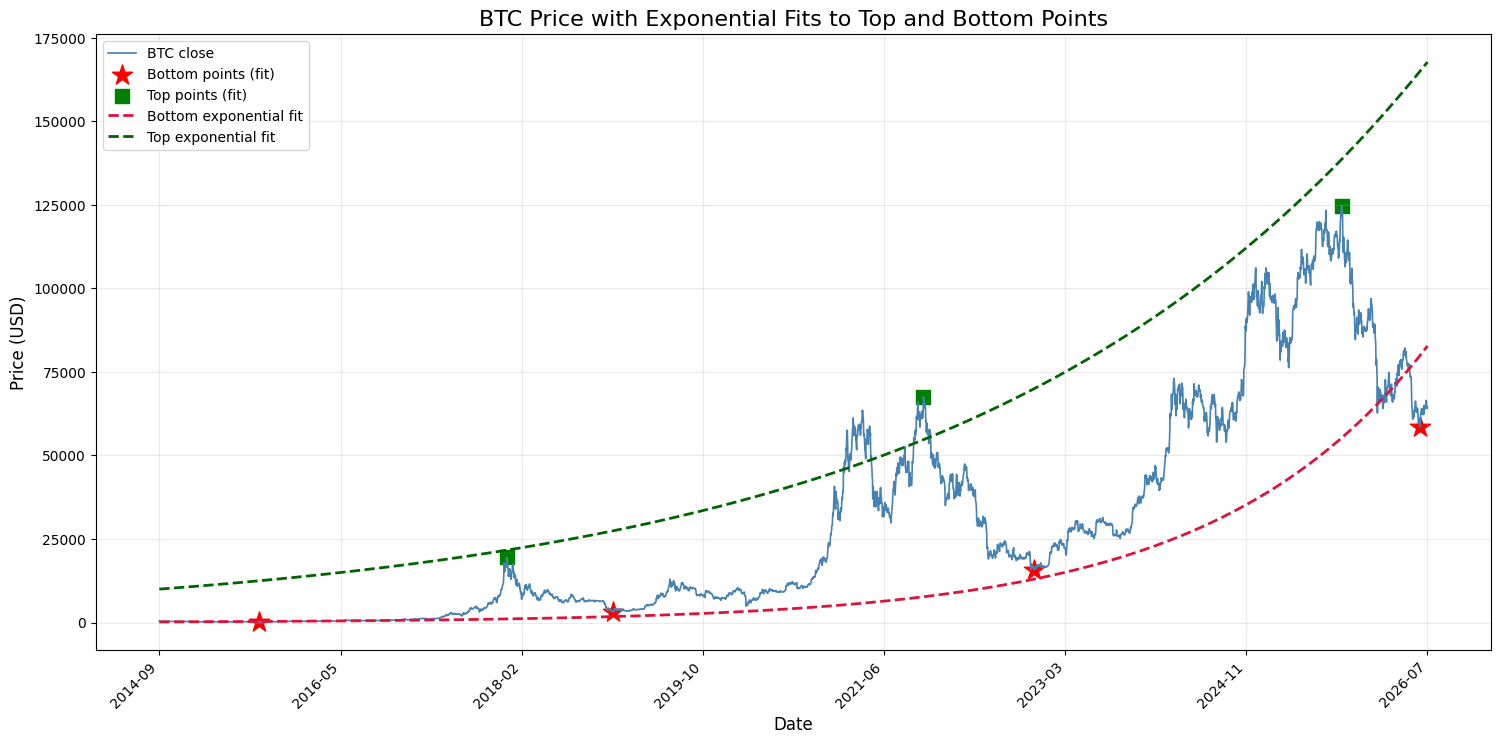

Bottom curve: price = 211.5937 * exp(0.001379 * idx)
Top curve   : price = 10014.0845 * exp(0.000651 * idx)


In [275]:
# Exponential growth fit for top and bottom points
bottom_idx_exp = np.array(sorted(int(i) for i in bottoms_list), dtype=float)
top_idx_exp = np.array(sorted(int(i) for i in tops_list), dtype=float)

bottom_prices_exp = df.loc[bottom_idx_exp.astype(int), 'c'].to_numpy(dtype=float)
top_prices_exp = df.loc[top_idx_exp.astype(int), 'c'].to_numpy(dtype=float)

if np.any(bottom_prices_exp <= 0) or np.any(top_prices_exp <= 0):
    raise ValueError('Exponential fit requires strictly positive prices.')

# Fit y = a * exp(b * x) by linearizing: ln(y) = ln(a) + b*x
bottom_b, bottom_log_a = np.polyfit(bottom_idx_exp, np.log(bottom_prices_exp), 1)
top_b, top_log_a = np.polyfit(top_idx_exp, np.log(top_prices_exp), 1)

bottom_a = np.exp(bottom_log_a)
top_a = np.exp(top_log_a)

x_line_exp = np.linspace(0, max(df.index.max(), bottom_idx_exp.max(), top_idx_exp.max()), 600)
bottom_curve = bottom_a * np.exp(bottom_b * x_line_exp)
top_curve = top_a * np.exp(top_b * x_line_exp)

fig, ax = plt.subplots(figsize=(18, 8))
ax.plot(df.index, df['c'], color='steelblue', linewidth=1.2, label='BTC close')
ax.scatter(bottom_idx_exp, bottom_prices_exp, color='red', marker='*', s=230, label='Bottom points (fit)')
ax.scatter(top_idx_exp, top_prices_exp, color='green', marker='s', s=100, label='Top points (fit)')

ax.plot(x_line_exp, bottom_curve, '--', color='crimson', linewidth=2, label='Bottom exponential fit')
ax.plot(x_line_exp, top_curve, '--', color='darkgreen', linewidth=2, label='Top exponential fit')

ax.set_title('BTC Price with Exponential Fits to Top and Bottom Points', fontsize=16)
tick_idx = np.linspace(df.index.min(), df.index.max(), 8)
tick_idx = np.unique(np.clip(np.round(tick_idx).astype(int), df.index.min(), df.index.max()))
tick_dates = pd.to_datetime(df.loc[tick_idx, 'Date'])
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_dates.dt.strftime('%Y-%m'), rotation=45, ha='right')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_yscale('linear')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
plt.show()

print(f'Bottom curve: price = {bottom_a:.4f} * exp({bottom_b:.6f} * idx)')
print(f'Top curve   : price = {top_a:.4f} * exp({top_b:.6f} * idx)')

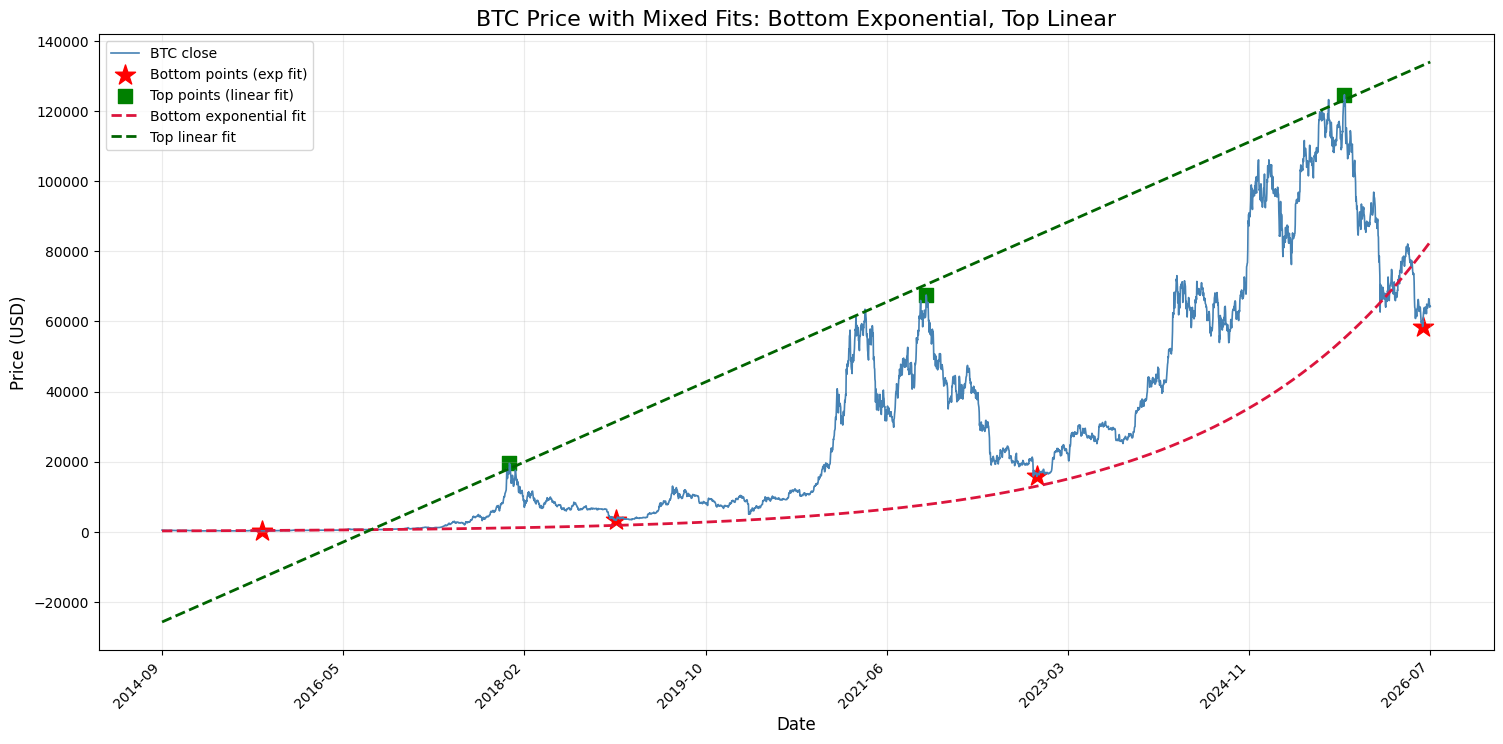

Bottom curve (exp): price = 211.5937 * exp(0.001379 * idx)
Top line (linear): price = 36.9205 * idx + -25781.54


In [276]:
# Mixed fit: exponential for bottoms, linear for tops
bottom_idx_mix = np.array(sorted(int(i) for i in bottoms_list), dtype=float)
top_idx_mix = np.array(sorted(int(i) for i in tops_list), dtype=float)

bottom_prices_mix = df.loc[bottom_idx_mix.astype(int), 'c'].to_numpy(dtype=float)
top_prices_mix = df.loc[top_idx_mix.astype(int), 'c'].to_numpy(dtype=float)

if np.any(bottom_prices_mix <= 0):
    raise ValueError('Exponential fit for bottoms requires strictly positive prices.')

# Bottoms: y = a * exp(b*x)
bottom_b_mix, bottom_log_a_mix = np.polyfit(bottom_idx_mix, np.log(bottom_prices_mix), 1)
bottom_a_mix = np.exp(bottom_log_a_mix)

# Tops: y = m*x + c
top_m_mix, top_c_mix = np.polyfit(top_idx_mix, top_prices_mix, 1)

x_line_mix = np.linspace(0, max(df.index.max(), bottom_idx_mix.max(), top_idx_mix.max()), 600)
bottom_curve_mix = bottom_a_mix * np.exp(bottom_b_mix * x_line_mix)
top_line_mix = top_m_mix * x_line_mix + top_c_mix

fig, ax = plt.subplots(figsize=(18, 8))
ax.plot(df.index, df['c'], color='steelblue', linewidth=1.2, label='BTC close')
ax.scatter(bottom_idx_mix, bottom_prices_mix, color='red', marker='*', s=230, label='Bottom points (exp fit)')
ax.scatter(top_idx_mix, top_prices_mix, color='green', marker='s', s=100, label='Top points (linear fit)')

ax.plot(x_line_mix, bottom_curve_mix, '--', color='crimson', linewidth=2, label='Bottom exponential fit')
ax.plot(x_line_mix, top_line_mix, '--', color='darkgreen', linewidth=2, label='Top linear fit')

ax.set_title('BTC Price with Mixed Fits: Bottom Exponential, Top Linear', fontsize=16)
tick_idx = np.linspace(df.index.min(), df.index.max(), 8)
tick_idx = np.unique(np.clip(np.round(tick_idx).astype(int), df.index.min(), df.index.max()))
tick_dates = pd.to_datetime(df.loc[tick_idx, 'Date'])
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_dates.dt.strftime('%Y-%m'), rotation=45, ha='right')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_yscale('linear')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
plt.show()

print(f'Bottom curve (exp): price = {bottom_a_mix:.4f} * exp({bottom_b_mix:.6f} * idx)')
print(f'Top line (linear): price = {top_m_mix:.4f} * idx + {top_c_mix:.2f}')

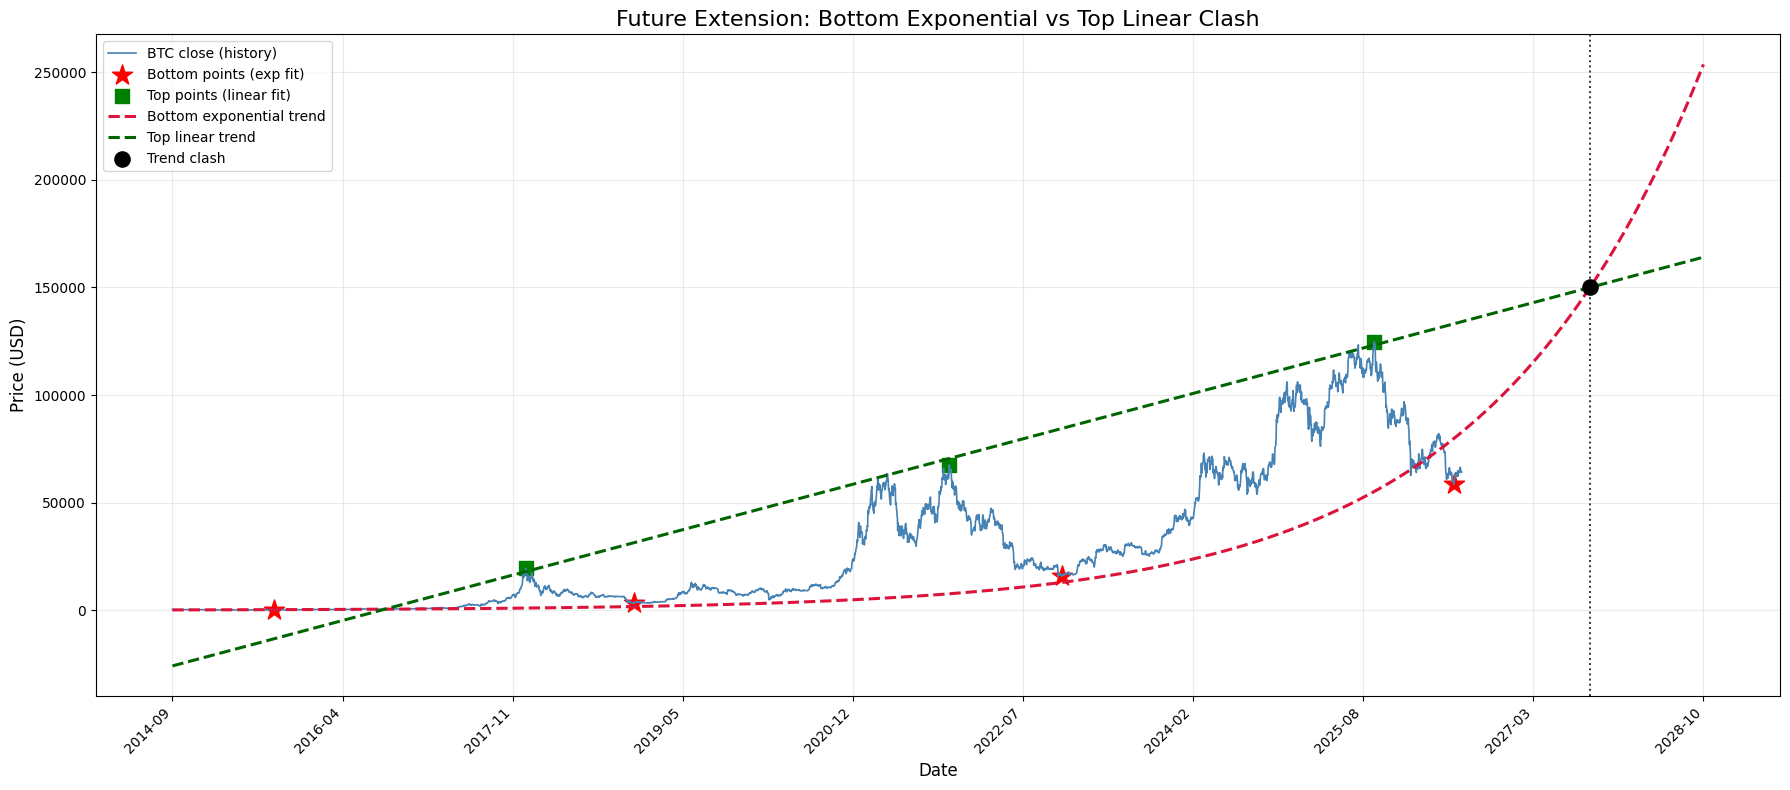

Bottom curve (exp): price = 211.5937 * exp(0.001379 * idx)
Top line (linear): price = 36.9205 * idx + -25781.54
Clash index: 4761.37
Clash date : 2027-09-30
Clash price: $150,010.51


In [277]:
# Future-extended mixed fit: bottom exponential vs top linear, with clash point
bottom_idx_future = np.array(sorted(int(i) for i in bottoms_list), dtype=float)
top_idx_future = np.array(sorted(int(i) for i in tops_list), dtype=float)

bottom_prices_future = df.loc[bottom_idx_future.astype(int), 'c'].to_numpy(dtype=float)
top_prices_future = df.loc[top_idx_future.astype(int), 'c'].to_numpy(dtype=float)

if np.any(bottom_prices_future <= 0):
    raise ValueError('Exponential fit for bottoms requires strictly positive prices.')

# Bottoms: y = a * exp(b*x)
bottom_b_future, bottom_log_a_future = np.polyfit(bottom_idx_future, np.log(bottom_prices_future), 1)
bottom_a_future = np.exp(bottom_log_a_future)

# Tops: y = m*x + c
top_m_future, top_c_future = np.polyfit(top_idx_future, top_prices_future, 1)

def bottom_exp(x):
    return bottom_a_future * np.exp(bottom_b_future * x)

def top_lin(x):
    return top_m_future * x + top_c_future

def f_clash(x):
    return bottom_exp(x) - top_lin(x)

# Date mapping from index for out-of-sample future points
idx_min = float(df.index.min())
idx_max = float(df.index.max())
start_date = pd.to_datetime(df.loc[int(idx_min), 'Date'])
end_date = pd.to_datetime(df.loc[int(idx_max), 'Date'])

days_per_index = (end_date - start_date).days / (idx_max - idx_min)

def date_from_index(x):
    return start_date + pd.to_timedelta((x - idx_min) * days_per_index, unit='D')

# Find future intersection by expanding search window until sign change
left = idx_max
f_left = f_clash(left)

if f_left >= 0:
    right = left
else:
    step = 365.0
    right = left + step
    f_right = f_clash(right)
    expand_iter = 0

    while f_left * f_right > 0 and expand_iter < 60:
        step *= 1.5
        right = left + step
        f_right = f_clash(right)
        expand_iter += 1

    if f_left * f_right > 0:
        raise RuntimeError('Could not find a future clash window. Try adjusting fit points.')

# Bisection solve on [left, right]
if f_left >= 0:
    x_clash = left
else:
    lo, hi = left, right
    for _ in range(120):
        mid = 0.5 * (lo + hi)
        f_mid = f_clash(mid)
        if f_left * f_mid <= 0:
            hi = mid
        else:
            lo = mid
            f_left = f_mid
    x_clash = 0.5 * (lo + hi)

p_clash = float(bottom_exp(x_clash))
d_clash = date_from_index(x_clash)

# Extend chart beyond clash so curves are clearly seen meeting
x_end = max(idx_max, x_clash * 1.08)
x_line_future = np.linspace(idx_min, x_end, 900)
bottom_curve_future = bottom_exp(x_line_future)
top_line_future = top_lin(x_line_future)

fig, ax = plt.subplots(figsize=(18, 8))
ax.plot(df.index, df['c'], color='steelblue', linewidth=1.2, label='BTC close (history)')
ax.scatter(bottom_idx_future, bottom_prices_future, color='red', marker='*', s=230, label='Bottom points (exp fit)')
ax.scatter(top_idx_future, top_prices_future, color='green', marker='s', s=100, label='Top points (linear fit)')

ax.plot(x_line_future, bottom_curve_future, '--', color='crimson', linewidth=2.2, label='Bottom exponential trend')
ax.plot(x_line_future, top_line_future, '--', color='darkgreen', linewidth=2.2, label='Top linear trend')

ax.scatter([x_clash], [p_clash], color='black', s=120, zorder=6, label='Trend clash')
ax.axvline(x_clash, color='black', linestyle=':', linewidth=1.4, alpha=0.8)

ax.set_title('Future Extension: Bottom Exponential vs Top Linear Clash', fontsize=16)

tick_idx = np.linspace(idx_min, x_end, 10)
tick_dates = [date_from_index(x) for x in tick_idx]
ax.set_xticks(tick_idx)
ax.set_xticklabels([d.strftime('%Y-%m') for d in tick_dates], rotation=45, ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_yscale('linear')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

print(f'Bottom curve (exp): price = {bottom_a_future:.4f} * exp({bottom_b_future:.6f} * idx)')
print(f'Top line (linear): price = {top_m_future:.4f} * idx + {top_c_future:.2f}')
print(f'Clash index: {x_clash:.2f}')
print(f'Clash date : {d_clash.date()}')
print(f'Clash price: ${p_clash:,.2f}')